In [9]:
import pandas as pd

import sys
from pathlib import Path
PROJECT_ROOT = Path().resolve()
while not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT))


from src.features import (
    add_lagged_returns,
    add_moving_average_features,
    add_volatility_features
)

from src.volatility import add_close_to_close_volatility
from src.labeling import add_returns

In [10]:
df = pd.read_csv("../data/raw/nifty50.csv", parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)

reg = pd.read_csv("../data/processed/hmm_regimes.csv", parse_dates=["Date"])

df = df.merge(reg[["Date", "hmm_regime"]], on="Date", how="left")

In [11]:
df = add_returns(df)
df = add_close_to_close_volatility(df)

df = add_lagged_returns(df)
df = add_moving_average_features(df)
df = add_volatility_features(df, vol_col="vol_cc")

In [13]:
df["target_ret"] = df["return"].shift(-1) #binary to continuous returns

In [15]:
features = [
    "ret_lag_1","ret_lag_5","ret_lag_10",
    "ma_ratio_5","ma_ratio_10","ma_ratio_20",
    "vol_cc","vol_cc_lag_1"
]

data = df.dropna(subset=features + ["target_ret", "hmm_regime"]).copy()
data.tail()

,Date,Open,High,Low,Close,Volume,hmm_regime,return,vol_cc,ret_lag_1,ret_lag_5,ret_lag_10,ma_ratio_5,ma_ratio_10,ma_ratio_20,vol_cc_lag_1,target_ret
4515,2026-02-12,25906.699219,25906.699219,25752.400391,25807.199219,419400,Low,-0.005650,0.130152,0.000721,-0.005168,0.003005,0.998289,1.004904,1.011207,0.128685,-0.013023
4516,2026-02-13,25571.150391,25630.349609,25444.300781,25471.099609,453500,Medium,-0.013023,0.138191,-0.005650,0.001985,-0.003865,0.986987,0.991236,0.998418,0.130152,0.008309
4517,2026-02-16,25423.599609,25697.000000,25372.699219,25682.750000,275800,Low,0.008309,0.141515,-0.013023,0.006757,-0.009172,0.996614,0.997166,1.006737,0.138191,0.001661
4518,2026-02-17,25637.949219,25764.400391,25570.300781,25725.400391,344100,Medium,0.001661,0.140728,0.008309,0.002623,0.025476,0.999897,0.998830,1.008133,0.141515,0.003652
4519,2026-02-18,25752.650391,25828.050781,25645.150391,25819.349609,310200,Low,0.003652,0.130728,0.001661,0.000721,0.001883,1.004599,1.002309,1.010652,0.140728,-0.014137


In [16]:
split = int(len(data) * 0.8)

train = data.iloc[:split]
test = data.iloc[split:]

X_train = train[features]
y_train = train["target_ret"]

X_test = test[features]
y_test = test["target_ret"]

# **Quantile Gradient Boosting**

In [17]:
from sklearn.ensemble import GradientBoostingRegressor

def train_quantile(alpha):
    model = GradientBoostingRegressor(
        loss="quantile",
        alpha=alpha,
        n_estimators=300,
        max_depth=3,
        min_samples_leaf=50,
        random_state=42
    )
    model.fit(X_train, y_train)
    return model

q10_model = train_quantile(0.1)
q50_model = train_quantile(0.5)
q90_model = train_quantile(0.9)

In [19]:
test["q10"] = q10_model.predict(X_test)
test["q50"] = q50_model.predict(X_test)
test["q90"] = q90_model.predict(X_test)

In [20]:
test["interval_width"] = test["q90"] - test["q10"] #width = forecast uncertainity proxy

In [22]:
test["covered"] = (
    (test["target_ret"] >= test["q10"]) &
    (test["target_ret"] <= test["q90"])
).astype(int)
#Checks if true return lies inside [q10, q90]

In [23]:
#regime metrics
regime_stats = test.groupby("hmm_regime").agg(
    mean_return=("target_ret","mean"),
    width=("interval_width","mean"),
    coverage=("covered","mean"),
    median_pred=("q50","mean"),
    count=("target_ret","size")
).reset_index()

regime_stats

,hmm_regime,mean_return,width,coverage,median_pred,count
0,High,0.003517,0.027081,0.795455,0.001323,44
1,Low,0.000796,0.018219,0.815421,0.000337,428
2,Medium,0.000019,0.018200,0.799065,0.000314,428


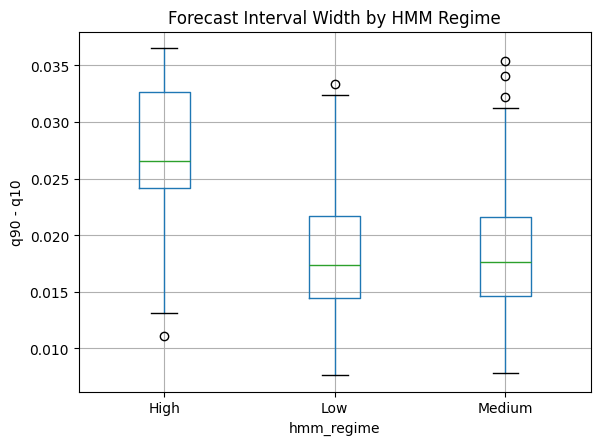

In [24]:
import matplotlib.pyplot as plt

test.boxplot(column="interval_width", by="hmm_regime")
plt.title("Forecast Interval Width by HMM Regime")
plt.suptitle("")
plt.ylabel("q90 - q10")
plt.show()

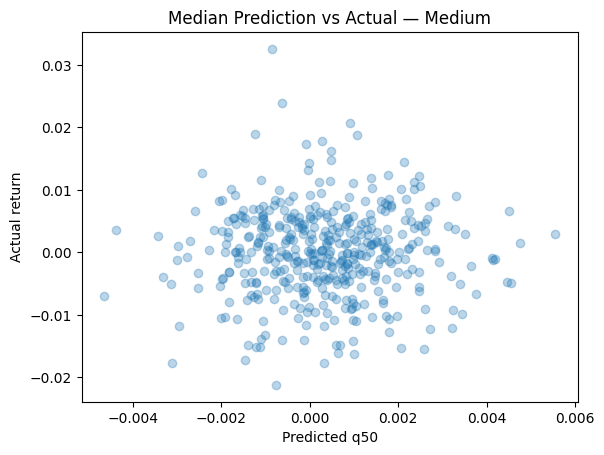

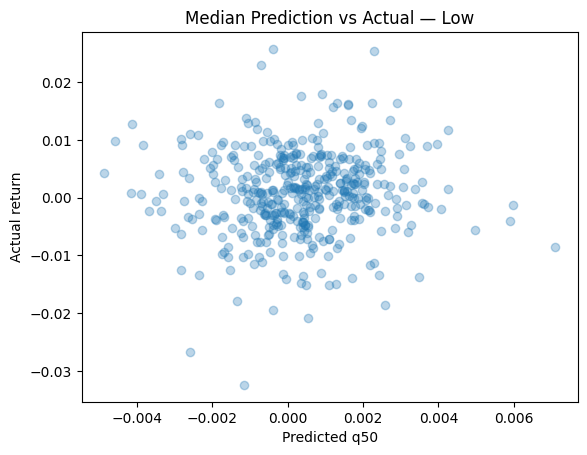

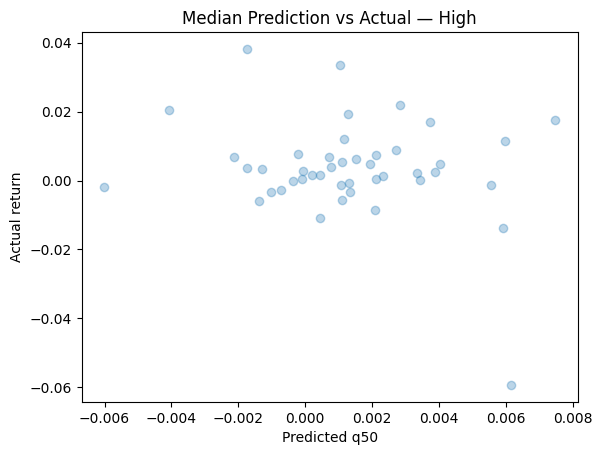

In [25]:
for r in test["hmm_regime"].unique():
    subset = test[test["hmm_regime"] == r]
    
    plt.figure()
    plt.scatter(subset["q50"], subset["target_ret"], alpha=0.3)
    plt.title(f"Median Prediction vs Actual — {r}")
    plt.xlabel("Predicted q50")
    plt.ylabel("Actual return")
    plt.show()

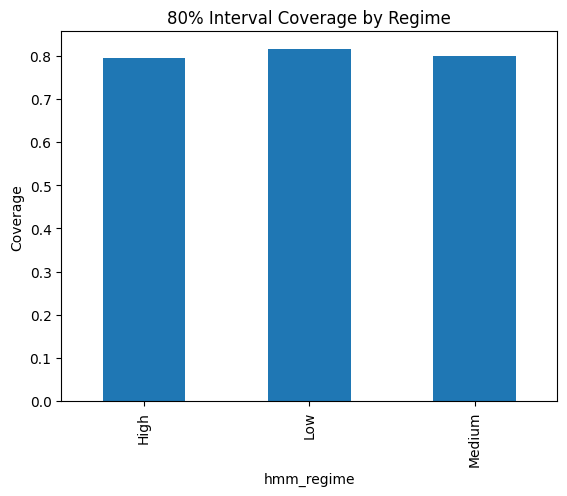

In [26]:
coverage_plot = test.groupby("hmm_regime")["covered"].mean()

coverage_plot.plot(kind="bar")
plt.title("80% Interval Coverage by Regime")
plt.ylabel("Coverage")
plt.show()